## Metropolis-Hastings 算法

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 定义目标分布（双峰分布）
def target_distribution(x):
    """目标分布：两个高斯分布的混合"""
    return 0.4 * norm.pdf(x, loc=20, scale=3) + 0.6 * norm.pdf(x, loc=40, scale=8)

# Metropolis-Hastings 算法
def metropolis_hastings(n_samples, initial_value, proposal_std):
    samples = np.zeros(n_samples)
    samples[0] = initial_value
    accepted = 0
    
    for i in range(1, n_samples):
        # 从提议分布中生成候选样本
        candidate = np.random.normal(samples[i-1], proposal_std)
        
        # 计算接受概率
        acceptance_ratio = target_distribution(candidate) / target_distribution(samples[i-1])
        
        # 决定是否接受候选样本
        if np.random.rand() < acceptance_ratio:
            samples[i] = candidate
            accepted += 1
        else:
            samples[i] = samples[i-1]
    
    acceptance_rate = accepted / (n_samples - 1)
    return samples, acceptance_rate

# 参数设置
seed = 42
n_samples = 10000
burn_in = 1000  # 燃烧期

# 运行MCMC采样
samples, acceptance_rate = metropolis_hastings(n_samples, initial_value=25, proposal_std=8)

# 去除燃烧期的样本
post_burn_samples = samples[burn_in:]


AttributeError: 'Axes' object has no attribute 'kde'

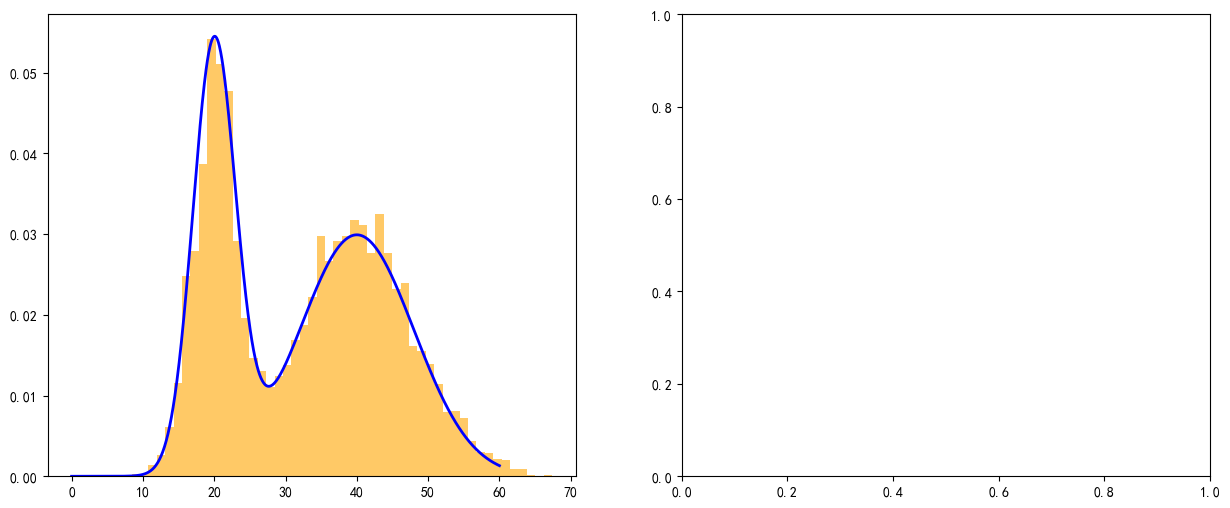

In [2]:

# 绘制结果
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 左图：目标分布和采样路径
x = np.linspace(0, 60, 1000)
y_true = target_distribution(x)

ax1.plot(x, y_true, 'b-', linewidth=2, label='目标分布')
ax1.hist(post_burn_samples, bins=50, density=True, alpha=0.6, color='orange', label='采样分布')
ax1.kde(post_burn_samples, bw_method='scott', color='red', label='采样密度估计')
ax1.set_xlabel('参数值')
ax1.set_ylabel('概率密度')
ax1.set_title('MCMC采样结果\n目标分布 vs 采样分布')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图：采样链的轨迹
ax2.plot(post_burn_samples, linewidth=0.5)
ax2.set_xlabel('迭代次数')
ax2.set_ylabel('参数值')
ax2.set_title(f'MCMC采样链 (接受率: {acceptance_rate:.2%})')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 输出统计信息
print(f"采样统计信息:")
print(f"总样本数: {n_samples}")
print(f"燃烧期后样本数: {len(post_burn_samples)}")
print(f"接受率: {acceptance_rate:.2%}")
print(f"样本均值: {np.mean(post_burn_samples):.2f}")
print(f"样本标准差: {np.std(post_burn_samples):.2f}")


绘制图形-Python 代码

1. 采用 area graph 展示真实分布
2. 将上述过程执行 10 次，形成 10 组 post_burn_samples，即上一个单元格中左图中的黄色直方图对应的数据，采用 kdensity 展示。
3. 最终形成的图形是：真实分布的 area graph 和 10 个采样分布的 kdensity 图叠加在一起。

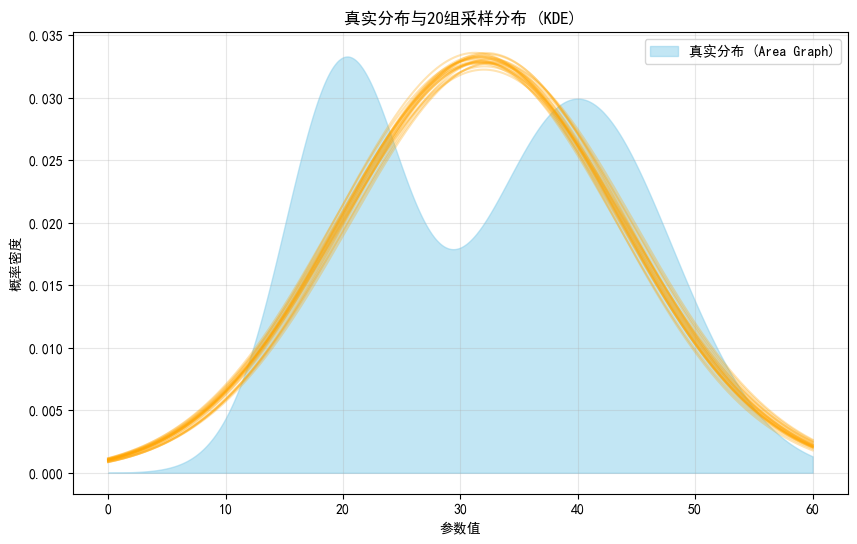

In [5]:
plt.figure(figsize=(10, 6))
x = np.linspace(0, 60, len(y_true))
plt.fill_between(x, y_true, color='skyblue', alpha=0.5, label='真实分布 (Area Graph)')

# 生成 10 组 post_burn_samples 并绘制 KDE
for i in range(10):
    samples_i, _ = metropolis_hastings(n_samples, initial_value=25, proposal_std=8)
    post_burn_i = samples_i[burn_in:]
    kde = norm(loc=np.mean(post_burn_i), scale=np.std(post_burn_i))
    plt.plot(x, kde.pdf(x), color='orange', alpha=0.3)

plt.xlabel('参数值')
plt.ylabel('概率密度')
plt.title('真实分布与20组采样分布 (KDE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23616\150153005.py:90: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23616\150153005.py:90: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23616\150153005.py:90: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23616\150153005.py:90: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23616\150153005.py:90: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23616\15

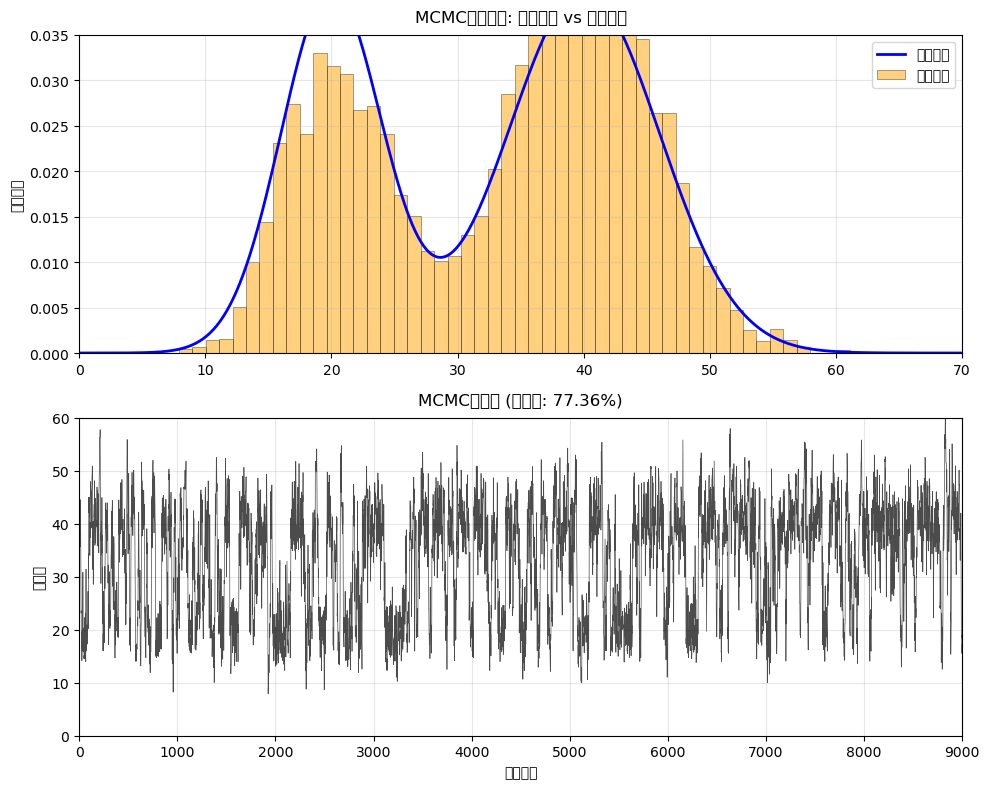

接受率: 77.36%
样本均值: 33.33
样本标准差: 10.68


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置图形风格更接近原图
plt.style.use('default')

# 定义目标分布 - 更接近原图的双峰分布
def target_distribution(x):
    """目标分布：两个高斯分布的混合，调整参数以匹配原图"""
    return (0.4 * norm.pdf(x, loc=20, scale=4) + 
            0.6 * norm.pdf(x, loc=40, scale=6))

# Metropolis-Hastings 算法
def metropolis_hastings(n_samples, initial_value, proposal_std):
    samples = np.zeros(n_samples)
    samples[0] = initial_value
    accepted = 0
    
    for i in range(1, n_samples):
        # 从提议分布中生成候选样本
        candidate = np.random.normal(samples[i-1], proposal_std)
        
        # 计算接受概率
        current_prob = target_distribution(samples[i-1])
        candidate_prob = target_distribution(candidate)
        
        # 避免除以零
        if current_prob == 0:
            acceptance_ratio = 1
        else:
            acceptance_ratio = candidate_prob / current_prob
        
        # 决定是否接受候选样本
        if np.random.rand() < min(1, acceptance_ratio):
            samples[i] = candidate
            accepted += 1
        else:
            samples[i] = samples[i-1]
    
    acceptance_rate = accepted / (n_samples - 1)
    return samples, acceptance_rate

# 参数设置
np.random.seed(42)  # 设置随机种子以便结果可重现
n_samples = 10000
burn_in = 1000

# 运行MCMC采样
samples, acceptance_rate = metropolis_hastings(n_samples, initial_value=25, proposal_std=5)

# 去除燃烧期的样本
post_burn_samples = samples[burn_in:]

# 创建图形 - 更接近原图的布局
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# 生成x轴数据
x = np.linspace(0, 70, 1000)
y_true = target_distribution(x)

# 上图：目标分布和采样分布
ax1.plot(x, y_true, 'b-', linewidth=2, label='目标分布')
# 使用直方图显示采样分布
ax1.hist(post_burn_samples, bins=50, density=True, alpha=0.5, color='orange', 
         label='采样分布', edgecolor='black', linewidth=0.5)
ax1.set_xlim(0, 70)
ax1.set_ylim(0, 0.035)
ax1.set_ylabel('概率密度')
ax1.set_title('MCMC采样结果: 目标分布 vs 采样分布', fontsize=12, pad=10)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 设置x轴刻度更接近原图
ax1.set_xticks([0, 10, 20, 30, 40, 50, 60, 70])

# 下图：采样链的轨迹
ax2.plot(post_burn_samples, 'k-', linewidth=0.5, alpha=0.7)
ax2.set_xlim(0, len(post_burn_samples))
ax2.set_ylim(0, 60)
ax2.set_xlabel('迭代次数')
ax2.set_ylabel('参数值')
ax2.set_title(f'MCMC采样链 (接受率: {acceptance_rate:.2%})', fontsize=12, pad=10)
ax2.grid(True, alpha=0.3)

# 设置y轴刻度
ax2.set_yticks([0, 10, 20, 30, 40, 50, 60])

# 调整子图间距
plt.tight_layout()

# 显示图形
plt.show()

# 输出统计信息
print(f"接受率: {acceptance_rate:.2%}")
print(f"样本均值: {np.mean(post_burn_samples):.2f}")
print(f"样本标准差: {np.std(post_burn_samples):.2f}")